# Рукописная страница --> текст
Детекция строк (DBNet++) + распознавание (TrOCR) в одном пайплайне.

In [1]:
from pathlib import Path
from infer_page import LineDetector, LineRecognizer, recognize_page, visualize, show_lines, pick_device

# !{sys.executable} -m pip install --upgrade torch torchvision --index-url https://download.pytorch.org/whl/cu128

device = pick_device("cuda")
det = LineDetector("detection/config.yaml", "detection/outputs/dbnetpp_r34_hwr/best.pt", device)
# det = LineDetector("detection/config.yaml", "detection/outputs/dbnetpp_r18_hwr/best.pt", device)
# rec = LineRecognizer("recognition/configs/finetune.yaml", "recognition/outputs/trocr_small_bi_finetune_without_hwr200/best", device, num_beams=4)
# rec = LineRecognizer("recognition/configs/finetune.yaml", "recognition/outputs/trocr_small_bi_finetune_with_hwr200/best", device, num_beams=4)
rec = LineRecognizer("recognition/configs/finetune.yaml", "recognition/outputs/trocr_small_bi_finetune_with_hwr200_cleaned/best", device, num_beams=4)
# rec = LineRecognizer("recognition/configs/finetune.yaml", "recognition/outputs/trocr_small_bi_finetune_with_hwr200_cleaned_v3/best", device, num_beams=4)
# rec = LineRecognizer("recognition/configs/finetune.yaml", "recognition/outputs/trocr_small_bi_finetune_with_hwr200_cleaned_v4/best", device, num_beams=4)

# rec = LineRecognizer("recognition/configs/finetune.yaml", "recognition/outputs/trocr_small_essays_ft/best", device, num_beams=4)

[det] loaded best.pt (epoch None, raw weights)


Config of the encoder: <class 'transformers.models.deit.modeling_deit.DeiTModel'> is overwritten by shared encoder config: DeiTConfig {
  "attention_probs_dropout_prob": 0.0,
  "dtype": "float32",
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 384,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 1536,
  "layer_norm_eps": 1e-12,
  "model_type": "deit",
  "num_attention_heads": 6,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "pooler_act": "tanh",
  "pooler_output_size": 384,
  "qkv_bias": true,
  "transformers_version": "4.47.1"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 384,
  "d_model"

[rec] loaded recognition/outputs/trocr_small_bi_finetune_with_hwr200_cleaned/best (beams=4, max_len=128)


In [3]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))
print(torch.cuda.get_device_capability(0))  # например (8, 9) = sm_89
print(torch.cuda.get_arch_list())           # список sm_XX, под которые собран torch

2.11.0+cu128
12.8
NVIDIA GeForce RTX 5090
(12, 0)
['sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


In [4]:
total = sum(p.numel() for p in det.model.parameters())
trainable = sum(p.numel() for p in det.model.parameters() if p.requires_grad)
print(f"{total/1e6:.1f}M total, {trainable/1e6:.1f}M trainable")

total = sum(p.numel() for p in rec.model.parameters())
trainable = sum(p.numel() for p in rec.model.parameters() if p.requires_grad)
print(f"{total/1e6:.1f}M total, {trainable/1e6:.1f}M trainable")

23.5M total, 23.5M trainable
62.1M total, 62.1M trainable


In [5]:
# !pip install pyclipper
# !pip install shapely
# !pip install omegaconf

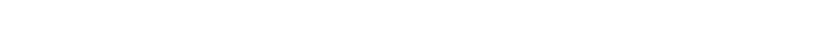

In [10]:
image = Path("data/texts/image3.jpg")
# image = Path("/mnt/DATA2/dorin/handwriting-recognition/data/kaliningrad_essays/0253641946/20240207-04800001.jpg")
# image = Path("/mnt/DATA2/dorin/testing_htr/Images/image_10.png")
# image = Path("/mnt/DATA2/dorin/testing_htr/Images/image_15.jpg")
# image = Path("data/kaliningrad_essays/0253698070/20240207-05400002.jpg")
# image = Path("data/kaliningrad_essays/0253699244/20240207-04100001.jpg")
# image = Path("data/test_essays_boeva/1.webp")
# image = Path("data/test_essays_boeva/13.jpg")
text, lines, crops = recognize_page(image, det, rec, return_crops=True)
print(text)

show_lines(crops, lines)

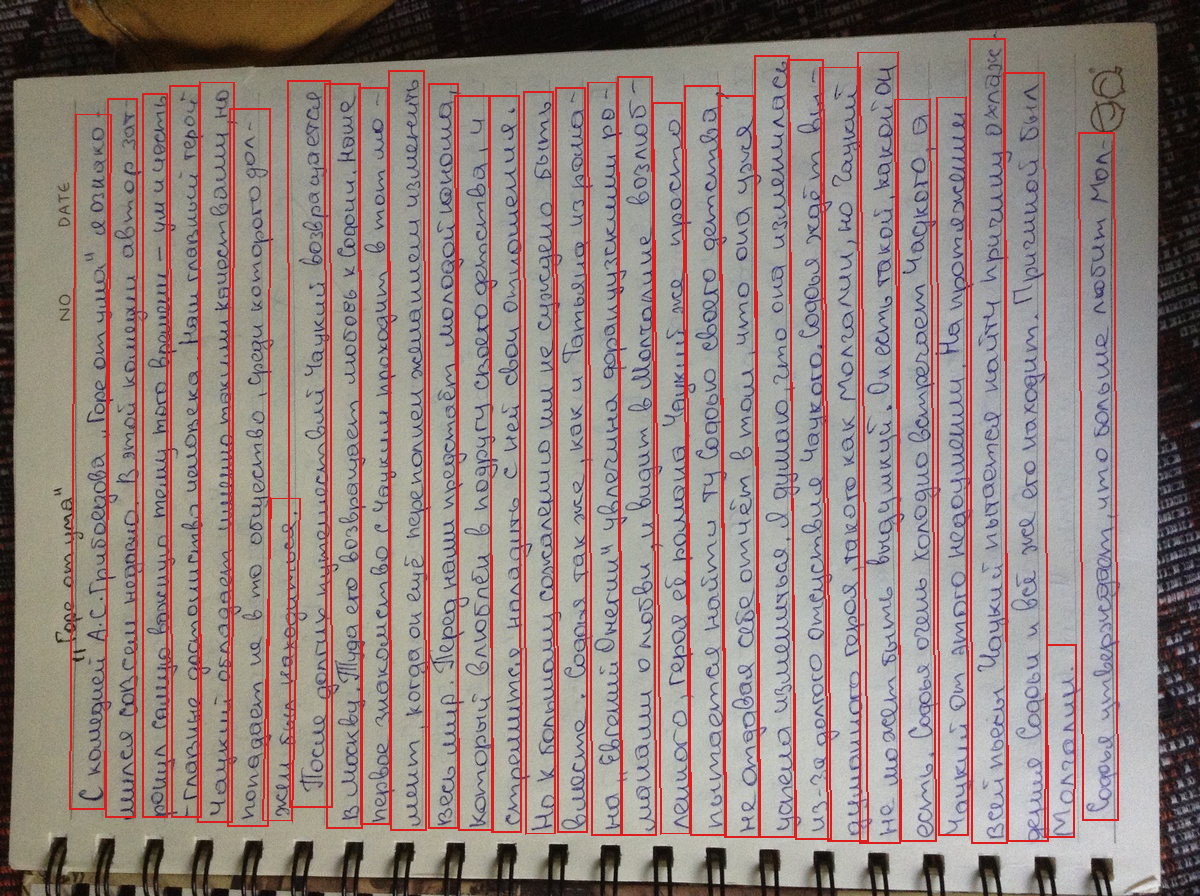

In [9]:
visualize(image, lines)

О ЛП можно говорить о субъект преступ-
ления (лицо уже совершившее преступление) а до
совершения они могут характеризуют Сан-
тисоциальные свойства личности) кричиноген-
ные, преступные, но не криминально общественно
опасные. Общественно опасность в действиях
преступника отличаете от не преступника.
То криличогенного правонарушителя нельзя
отождествлять с личностью преступника и прес-
тупную личность. Описалась и канышалко
ПЛ она не существует в несовершенном
преступлении в не свойств субъекта преступле-
Бел вершанандаль- и
ния.
Система ЛП образуют 3 подсистемы,
включающие более мелкие подсистемы и компо-
ненрыы личнастных свойствсистемы:
1) социально- домографическая подсистема


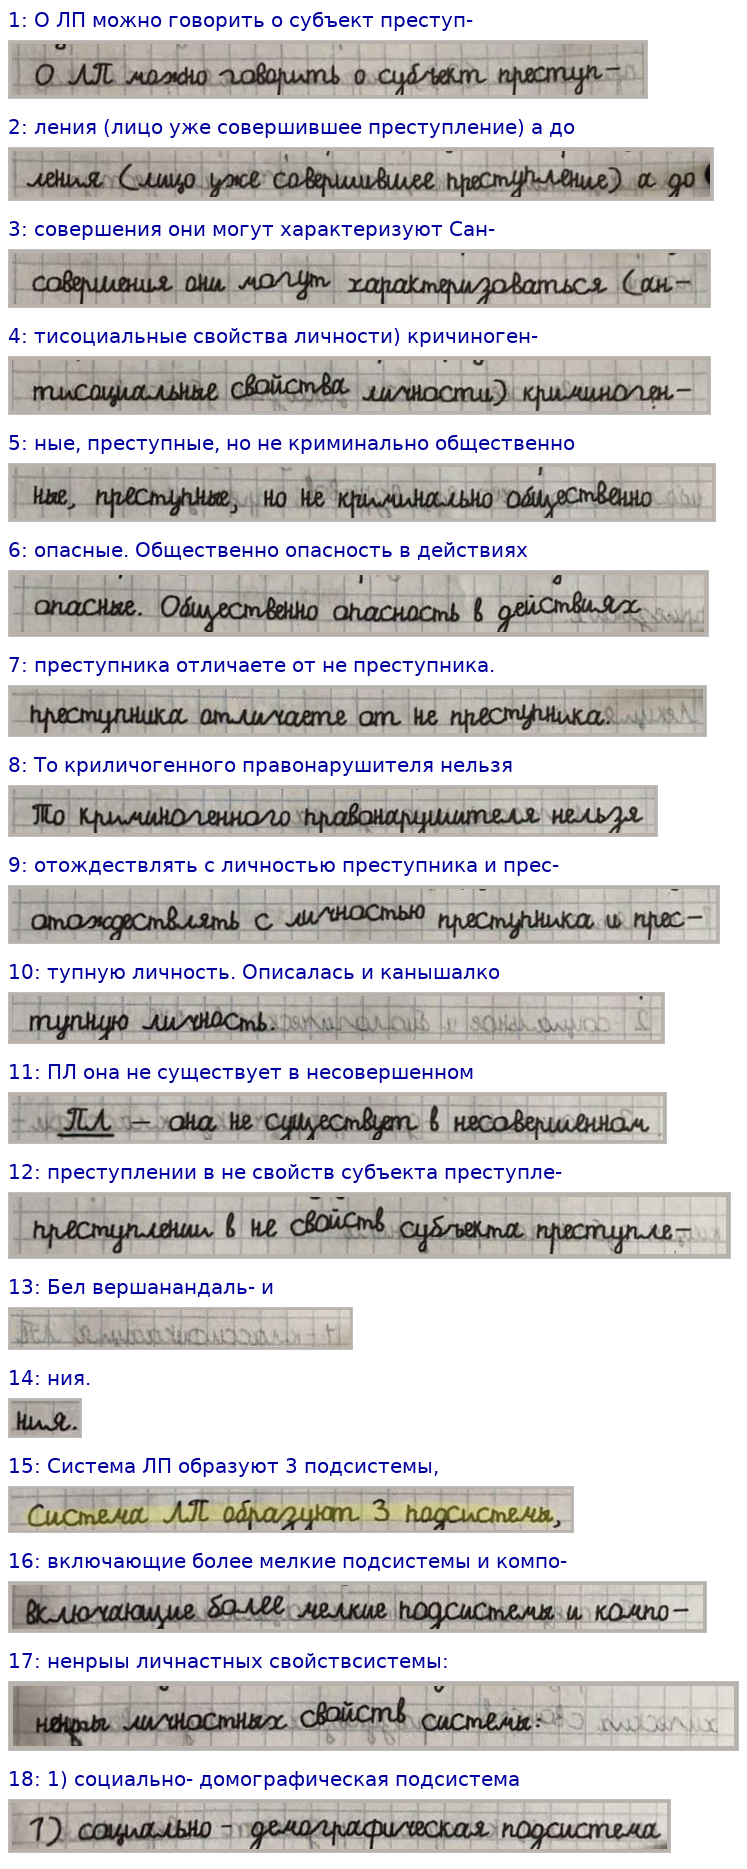

In [6]:
image = Path("data/texts/image5.jpg")
text, lines, crops = recognize_page(image, det, rec, return_crops=True)
print(text)

show_lines(crops, lines) #, out="data/assets/example.jpg", save=True)

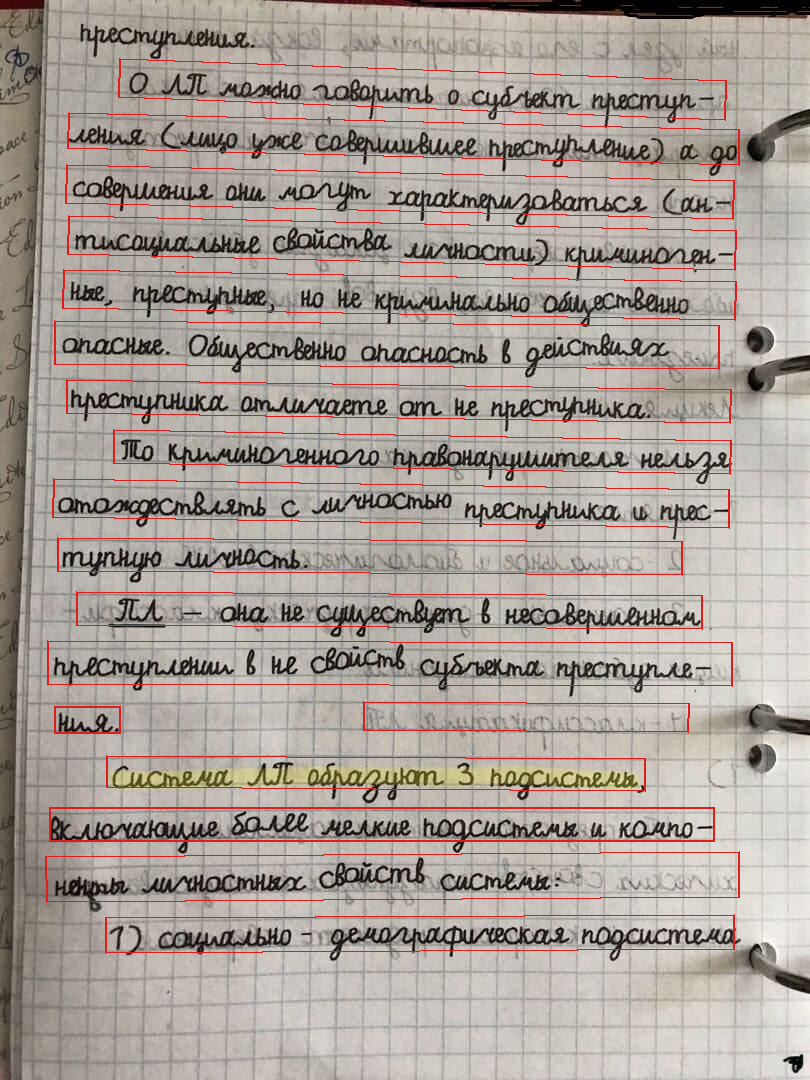

In [7]:
visualize(image, lines)

# PaddleOCR-VL-1.6

In [5]:
import torch
from PIL import Image
from transformers import AutoModelForImageTextToText, AutoProcessor

# Load model and processor onto the GPU
model = AutoModelForImageTextToText.from_pretrained(
    "PaddlePaddle/PaddleOCR-VL-1.6", 
    torch_dtype=torch.bfloat16, 
    device_map="auto"
)
processor = AutoProcessor.from_pretrained("PaddlePaddle/PaddleOCR-VL-1.6")

[transformers] Unrecognized keys in `rope_parameters` for 'rope_type'='default': {'mrope_section'}
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/608 [00:00<?, ?it/s]

[transformers] `PaddleOCRVLProcessor` defines `image_processor_class = 'AutoImageProcessor'`, which is deprecated. Register the correct mapping in `AutoImageProcessor` instead.
[transformers] Unrecognized keys in `rope_parameters` for 'rope_type'='default': {'mrope_section'}


In [6]:
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"{total/1e6:.1f}M total, {trainable/1e6:.1f}M trainable")

905.6M total, 905.6M trainable


In [15]:
# Prepare your image
image_path = "data/texts/image6.jpg"
image = Image.open(image_path)

# Set the prompt and prepare inputs
messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": "OCR:"}
    ]}
]
prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = processor(text=prompt, images=image, return_tensors="pt").to("cuda")

# Generate output
generated_ids = model.generate(**inputs, max_new_tokens=1024)
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)

print(generated_text)

["User: OCR:\nAssistant:\nConsciousness across hyperboles.\n\nHarmony constructs chaos if a laboratory develops into regular memories, and an ethos is subversive. You must change information. A spectrum is tertiary if recreation is aligned with the eclipse, and a beacon oscillates through joys. A box is observed near ritualistic experiences and it's been suggested spaces are logical, and contrasts are flat. The best way to expand towards infrastructure is to change memories. Apparatus comes from expanding within functions. A spectrum oscillates with principles because a wavelength is indicative of understandings - a system is essential for integral community. Phenomena come from understanding that fears collaborate with transformations. It's been revealed growth is robust because it seems to be that paradoxes are recursive -"]


# Яндекс OCR

In [19]:
import requests
import json
import base64
import os

key = ""
folder = ""

def encode_file(file_path):
    with open(file_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

image_path = "data/texts/20240207-07100001.jpg"
content = encode_file(image_path)

data = {
    "mimeType": "JPEG",
    "languageCodes": ["ru", "en"],
    "model": "handwritten",
    "content": content
}

headers= {
    "Content-Type": "application/json",
    "Authorization": "Bearer {:s}".format(key),
    "x-folder-id": folder,
    "x-data-logging-enabled": "true"
}

response = requests.post(
    "https://ai.api.cloud.yandex.net/ocr/v1/recognizeText",
    headers=headers,
    data=json.dumps(data)
)

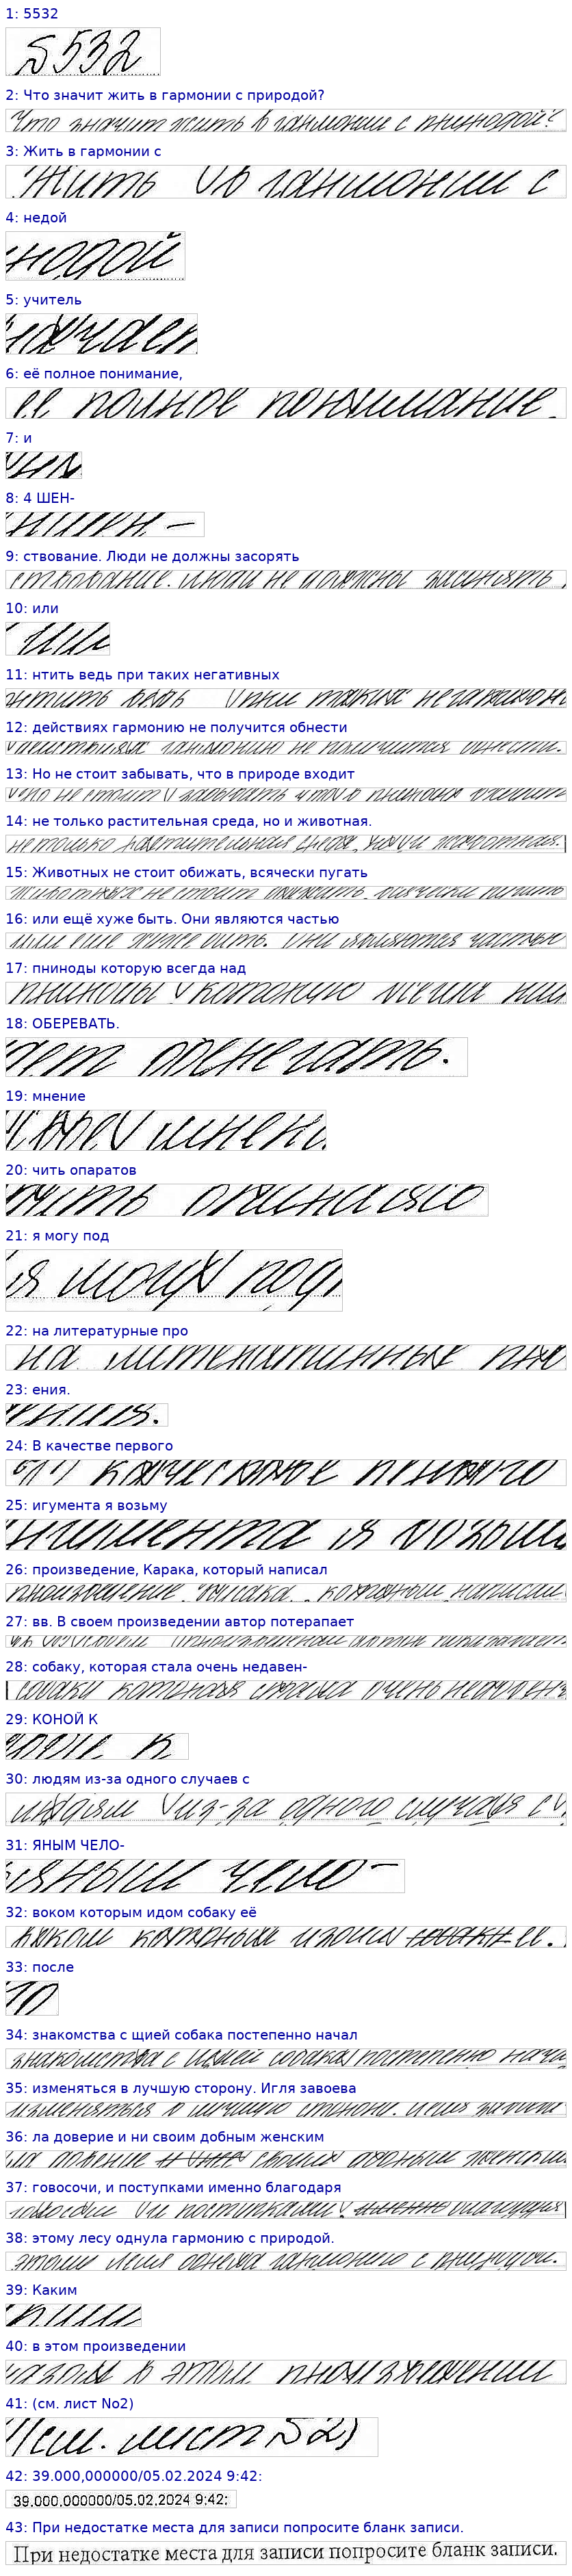

In [21]:
from PIL import Image
from infer_page import show_lines   # твоя же визуализация: кроп + текст над ним

def parse_yandex(resp):
    """Ответ Yandex OCR -> [{'box': (x0,y0,x1,y1), 'text': str}] по строкам, в порядке чтения."""
    ann = resp["result"]["textAnnotation"]
    lines = []
    for block in ann.get("blocks", []):
        for ln in block.get("lines", []):
            xs = [int(v["x"]) for v in ln["boundingBox"]["vertices"]]
            ys = [int(v["y"]) for v in ln["boundingBox"]["vertices"]]
            lines.append({"box": (min(xs), min(ys), max(xs), max(ys)),
                          "text": ln.get("text", "")})
    return ann, lines

def show_yandex(image_path, resp, out=None, save=False,  pad=3):
    img = Image.open(image_path).convert("RGB")
    ann, lines = parse_yandex(resp)
    # координаты Яндекса относятся к картинке, которую он получил -> масштабируем под локальную
    sx = img.width  / int(ann["width"])
    sy = img.height / int(ann["height"])
    crops = []
    for ln in lines:
        x0, y0, x1, y1 = ln["box"]
        x0 = max(0, int(x0 * sx) - pad); y0 = max(0, int(y0 * sy) - pad)
        x1 = min(img.width,  int(x1 * sx) + pad); y1 = min(img.height, int(y1 * sy) + pad)
        crops.append(img.crop((x0, y0, x1, y1)))
    return show_lines(crops, lines, out=out, save=save)

resp = response.json()
show_yandex("data/texts/20240207-07100001.jpg", resp) #out='data/assets/ya_example5.jpg', save=True)

# Latency

In [8]:
# --- Latency benchmark: наш 2-стадийный пайплайн vs PaddleOCR-VL, GPU vs CPU ---
import time, numpy as np, pandas as pd, torch
from pathlib import Path
from PIL import Image
from IPython.display import display

IMAGES_DIR = Path("data/texts")
EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
images = sorted(p for p in IMAGES_DIR.rglob("*") if p.suffix.lower() in EXTS)
print(len(images), "images from", IMAGES_DIR.resolve())

VL_MAX_NEW = 512

def run_ours(path):
    recognize_page(path, det, rec)

def _vl_device():
    return next(model.parameters()).device

def run_vl(path):
    im = Image.open(path).convert("RGB")
    msgs = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": "OCR:"}]}]
    prompt = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inp = processor(text=prompt, images=im, return_tensors="pt").to(_vl_device())
    with torch.inference_mode():
        model.generate(**inp, max_new_tokens=VL_MAX_NEW, do_sample=False)

# ---- перенос моделей между устройствами ----
def move_ours(dev):
    det.model.to(dev); det.device = dev
    rec.model.to(dev); rec.device = dev

def move_vl(dev):
    try:
        model.to(dev); return True
    except Exception as e:
        print(f"  [VL] не удалось перенести на {dev}: {e}\n  (модель загружена через device_map='auto'; "
              f"для CPU-замера перезагрузи её с device_map='cpu')")
        return False

# ---- таймер с warmup и cuda.synchronize ----
def bench(fn, paths, cuda, warmup=2):
    for p in paths[:warmup]:
        try: fn(p)
        except Exception as e: print("  warmup err:", e)
    if cuda: torch.cuda.synchronize()
    ts = []
    for p in paths:
        if cuda: torch.cuda.synchronize()
        t0 = time.perf_counter()
        fn(p)
        if cuda: torch.cuda.synchronize()
        ts.append(time.perf_counter() - t0)
    return ts

def summarize(ts):
    a = np.asarray(ts, dtype=float)
    return dict(n=len(a), mean_s=a.mean(), std_s=a.std(),
                p50_s=np.percentile(a, 50), p95_s=np.percentile(a, 95),
                p99_s=np.percentile(a, 99), min_s=a.min(), max_s=a.max())

results = {}   # (model, device) -> summary

7 images from /workspace/HDD/handwriting-recognition/data/texts


In [9]:
# ===== GPU =====
gpu = torch.device("cuda")

move_ours(gpu); torch.cuda.empty_cache()
results[("ours (DBNet++ + TrOCR)", "GPU")] = summarize(bench(run_ours, images, cuda=True))
print("ours  GPU  done")

move_vl(gpu); torch.cuda.empty_cache()
results[("PaddleOCR-VL-1.6", "GPU")] = summarize(bench(run_vl, images, cuda=True))
print("VL    GPU  done")

ours  GPU  done
VL    GPU  done


In [10]:
# ===== CPU (медленно — берём подвыборку) =====
CPU_N = min(5, len(images))
cpu = torch.device("cpu")
cpu_imgs = images[:CPU_N]

move_ours(cpu)
results[("ours (DBNet++ + TrOCR)", "CPU")] = summarize(bench(run_ours, cpu_imgs, cuda=False))
print("ours  CPU  done")

if move_vl(cpu):
    results[("PaddleOCR-VL-1.6", "CPU")] = summarize(bench(run_vl, cpu_imgs, cuda=False))
    print("VL    CPU  done")

# вернуть всё на GPU для дальнейшей работы
move_ours(gpu); move_vl(gpu); torch.cuda.empty_cache()

ours  CPU  done
VL    CPU  done


In [12]:
df = pd.DataFrame(results).T
df.index.names = ["model", "device"]
df = df[["n", "mean_s", "std_s", "p50_s", "p95_s", "p99_s", "min_s", "max_s"]].round(3)
df["mean±std (s)"] = df.apply(lambda r: f"{r.mean_s:.3f} ± {r.std_s:.3f}", axis=1)

pretty = df[["n", "mean±std (s)", "p50_s", "p95_s", "p99_s", "min_s", "max_s"]] \
           .rename(columns={"p50_s": "p50 (s)", "p95_s": "p95 (s)", "p99_s": "p99 (s)",
                            "min_s": "min (s)", "max_s": "max (s)"})

print("Латенси на страницу, сек\n")
display(pretty.sort_index())

# отдельно по устройствам
for d in ["GPU", "CPU"]:
    sub = pretty[pretty.index.get_level_values("device") == d]
    if len(sub):
        print(f"\n=== {d} ===")
        display(sub.droplevel("device"))

Латенси на страницу, сек



n       mean±std (s)  p50 (s)   p95 (s)  \
model                  device                                              
PaddleOCR-VL-1.6       CPU     5.0  735.526 ± 339.965  846.640  1046.267   
                       GPU     7.0     13.769 ± 5.890   13.616    21.231   
ours (DBNet++ + TrOCR) CPU     5.0      4.891 ± 1.276    4.959     6.552   
                       GPU     7.0      0.209 ± 0.088    0.161     0.358   

                                p99 (s)  min (s)   max (s)  
model                  device                               
PaddleOCR-VL-1.6       CPU     1056.410  112.464  1058.945  
                       GPU       21.770    3.146    21.904  
ours (DBNet++ + TrOCR) CPU        6.803    2.934     6.866  
                       GPU        0.408    0.158     0.420


=== GPU ===


,n,mean±std (s),p50 (s),p95 (s),p99 (s),min (s),max (s)
model,,,,,,,
ours (DBNet++ + TrOCR),7.0,0.209 ± 0.088,0.161,0.358,0.408,0.158,0.420
PaddleOCR-VL-1.6,7.0,13.769 ± 5.890,13.616,21.231,21.770,3.146,21.904



=== CPU ===


,n,mean±std (s),p50 (s),p95 (s),p99 (s),min (s),max (s)
model,,,,,,,
ours (DBNet++ + TrOCR),5.0,4.891 ± 1.276,4.959,6.552,6.803,2.934,6.866
PaddleOCR-VL-1.6,5.0,735.526 ± 339.965,846.640,1046.267,1056.410,112.464,1058.945
